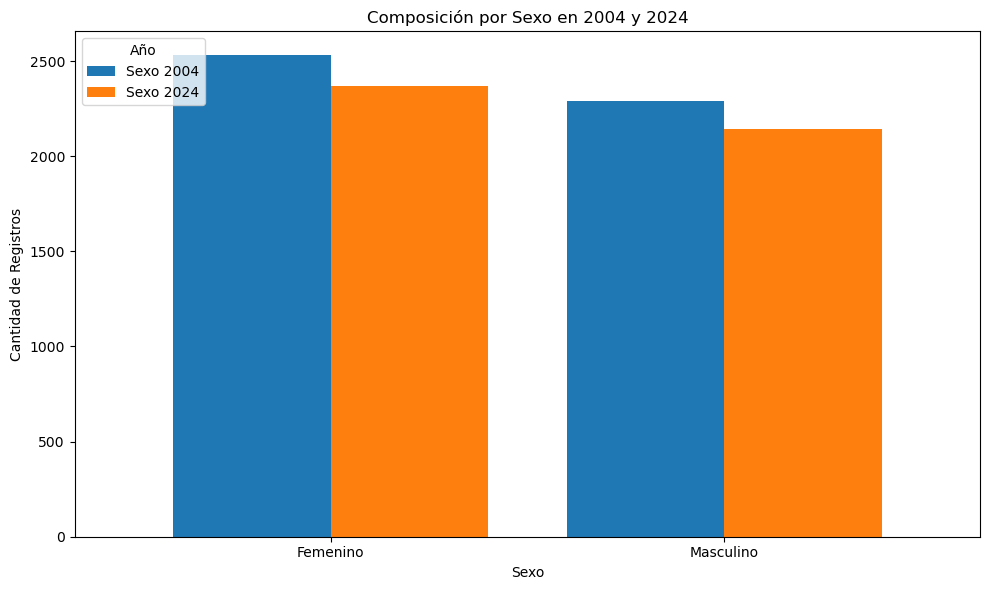

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar los datos de 2004 y 2024
base_2004 = pd.read_stata("C:/Users/CRIS/Documents/Big Data/Big Data Grupo 19/TP2/Individual_t104.dta")
base_2024 = pd.read_excel("C:/Users/CRIS/Documents/Big Data/Big Data Grupo 19/TP2/usu_individual_T124.xlsx")

# Filtrar por la región 42
base_2004 = base_2004[base_2004['region'] == "Cuyo"]
base_2024 = base_2024[base_2024["REGION"] == 42]

# Renombrar columnas en 2004 para que coincidan con las de 2024
renombrar_columnas_2004 = {
    'ch03': 'CH03',
    'ch04': 'CH04',
    'ch06': 'CH06',
    'ch07': 'CH07',
    'estado': 'ESTADO',
    'cat_ocup': 'CAT_OCUP',
    'pp3e_tot': 'PP3E_TOT',
    'p21': 'P21',
    'pp07h': 'PP07H',
    'nivel_ed': 'NIVEL_ED',
    'pp04b_cod': 'PP04B_COD',
    'pp04d_cod': 'PP04D_COD',
    'ch08': 'CH08',
    'pp07g2': 'PP07G2',
    'pp07g3': 'PP07G3',
    'cat_inac': 'CAT_INAC',
}
base_2004.rename(columns=renombrar_columnas_2004, inplace=True)


# Agregar columna 'año'
base_2004["año"] = 2004
base_2024["año"] = 2024

# Comprobar los valores únicos en 'CH04' para asegurar que el sexo está bien codificado
#print(base_2004['CH04'].unique())  # Se puede verificar los valores únicos en 'CH04' de 2004 borrando el "#"

# Si los valores están numéricamente codificados, reemplazarlos
#Utilicé "cat.rename_categories" en vez de "replace" en base_2004 ya que no estaban en valores numéricos
base_2004['CH04'] = base_2004['CH04'].cat.rename_categories({"Varón": 'Masculino', "Mujer": 'Femenino'})
base_2024['CH04'] = base_2024['CH04'].replace({1: 'Masculino', 2: 'Femenino'})

# Verificar los valores después del reemplazo (Verificar eliminando "#")
#print(base_2004['CH04'].unique())

# Contar la cantidad de registros para cada sexo en 2004 y 2024
sexo_2004 = base_2004['CH04'].value_counts()
sexo_2024 = base_2024['CH04'].value_counts()

# Convertir a un DataFrame para graficar
df_sexo = pd.DataFrame({
    'Sexo 2004': sexo_2004,
    'Sexo 2024': sexo_2024
}).fillna(0)  # Para manejar cualquier valor nulo si no hay registros en 2024 o 2004

# Graficar la composición por sexo
df_sexo.plot(kind='bar', figsize=(10,6), width=0.8)

# Agregar etiquetas y título
plt.title('Composición por Sexo en 2004 y 2024')
plt.xlabel('Sexo')
plt.ylabel('Cantidad de Registros')
plt.xticks(rotation=0)
plt.legend(title='Año', loc='upper left')

# Mostrar gráfico
plt.tight_layout()
plt.show()


In [2]:
# Filtrar solo los desocupados (ESTADO == 2)
base_2004_desocupados = base_2004[base_2004['ESTADO'] == "Desocupado"]
base_2024_desocupados = base_2024[base_2024['ESTADO'] == 2]

# Filtrar solo los inacvitos (ESTADO == 3)
base_2004_inactivos = base_2004[base_2004['ESTADO'] == "Inactivo"]
base_2024_inactivos = base_2024[base_2024['ESTADO'] == 3]

# Filtrar solo los ocupados (ESTADO == 1)
base_2004_ocupados = base_2004[base_2004['ESTADO'] == "Ocupado"]
base_2024_ocupados = base_2024[base_2024['ESTADO'] == 1]

#Creo una variable para dar un valor numérico a la cantidad que hay en las columnas
desocupados2004 = base_2004_desocupados["ESTADO"].count()
inactivos2004 = base_2004_inactivos["ESTADO"].count()
desocupados2024 = base_2024_desocupados["ESTADO"].count()
inactivos2024 = base_2024_inactivos["ESTADO"].count()


import numpy as np
#Definimos la media de los ocupados, desocupados e inactivos del 2004 y 2024 por separado
base_2004_ocupados_respuesta = base_2004_ocupados["ipcf"]
media_ocupados2004 = np.mean(base_2004_ocupados_respuesta)

base_2004_desocupados_respuesta = base_2004_desocupados["ipcf"]
media_desocupados2004 = np.mean(base_2004_desocupados_respuesta)

base_2004_inactivos_respuesta = base_2004_inactivos["ipcf"] 
media_inactivos2004 = np.mean(base_2004_inactivos_respuesta)

base_2024_ocupados_respuesta = base_2024_ocupados["IPCF"]
media_ocupados2024 = np.mean(base_2024_ocupados_respuesta)

base_2024_desocupados_respuesta = base_2024_desocupados["IPCF"]
media_desocupados2024 = np.mean(base_2024_desocupados_respuesta)

base_2024_inactivos_respuesta = base_2024_inactivos["IPCF"]
media_inactivos2024 = np.mean(base_2024_inactivos_respuesta)

#Como pide la parte III, aquí se hayan las respuestas de la pregunta 5 
print("Los desocupados en 2004 son:", desocupados2004)
print("Los inactivos en 2004 son:", inactivos2004)
print("Los desocupados en 2024 son:", desocupados2024)
print("Los inactivos en 2024 son:", inactivos2024)
print("La media de los ocupados en 2004 son:", media_ocupados2004)
print("La media de los desocupados en 2004 son:", media_desocupados2004)
print("La media de los inactivos en 2004 son:", media_inactivos2004)
print("La media de los ocupados en 2024 son:", media_ocupados2024)
print("La media de los desocupados en 2024 son:", media_desocupados2024)
print("La media de los inactivos en 2024 son:", media_inactivos2024)


Los desocupados en 2004 son: 223
Los inactivos en 2004 son: 1881
Los desocupados en 2024 son: 100
Los inactivos en 2024 son: 1816
La media de los ocupados en 2004 son: 334.83064163915503
La media de los desocupados en 2004 son: 173.56871597510613
La media de los inactivos en 2004 son: 256.5620696304109
La media de los ocupados en 2024 son: 187663.44854311197
La media de los desocupados en 2024 son: 107609.0052
La media de los inactivos en 2024 son: 148808.20412444937


In [3]:
respondieron = base_2024[base_2024['ESTADO'] != 0]
norespondieron = base_2024[base_2024['ESTADO'] == 0]

cantidad_norespondieron = norespondieron["ESTADO"].count()
print("No respondieron en 2024:", cantidad_norespondieron)

No respondieron en 2024: 6


In [ ]:
import seaborn as sns

# Variables seleccionadas
variables = ['CH04', 'CH06', 'CH07', 'CH08', 'NIVEL_ED', 'ESTADO', 'CAT_INAC', 'IPCF']
base_2004.rename(columns={'ipcf': 'IPCF'}, inplace=True)
# Función para preparar y codificar los datos
def preparar_datos(df, variables):
    df_seleccion = df[variables].copy()
    
    # Convertir variables categóricas a numéricas
    for col in df_seleccion.columns:
        if df_seleccion[col].dtype.name == 'category' or df_seleccion[col].dtype == 'object':
            df_seleccion[col] = pd.Categorical(df_seleccion[col]).codes
    return df_seleccion

# Preparar los datos
datos_2004 = preparar_datos(base_2004, variables)
datos_2024 = preparar_datos(base_2024, variables)

# Calcular matrices de correlación
corr_2004 = datos_2004.corr()
corr_2024 = datos_2024.corr()

# Visualizar matrices con heatmaps
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.heatmap(corr_2004, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación - 2004')

plt.subplot(1, 2, 2)
sns.heatmap(corr_2024, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación - 2024')

plt.tight_layout()
plt.show()